**Цель:**
1. Оценить информативность признаков
2. Проверить вклад факторов риска
3. Подтвердить корректность выбора признаков

In [1]:
import sys
from pathlib import Path
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent / 'src'
sys.path.append(str(ROOT))

from preprocessing import load_data, split_data
from feature_selection import calculate_mi_scores

In [2]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)

## Mutual Information
Метод Mutual Information позволяет оценить, насколько сильно признак связан с целевой переменной.
В отличие от корреляции,
метод способен учитывать нелинейные зависимости.

In [3]:
scores = calculate_mi_scores(X_train, y_train)
scores

,feature,label,mi_score
0,GenHlth,Общее состояние здоровья,0.092765
3,HighBP,Высокое кровяное давление,0.080832
1,BMI,ИМТ,0.056310
2,Age,Возрастная группа,0.043782
6,DiffWalk,Трудности при ходьбе,0.038059
5,HeartDiseaseorAttack,Болезни сердца/инфаркт,0.025020
4,PhysActivity,Физическая активность,0.019967


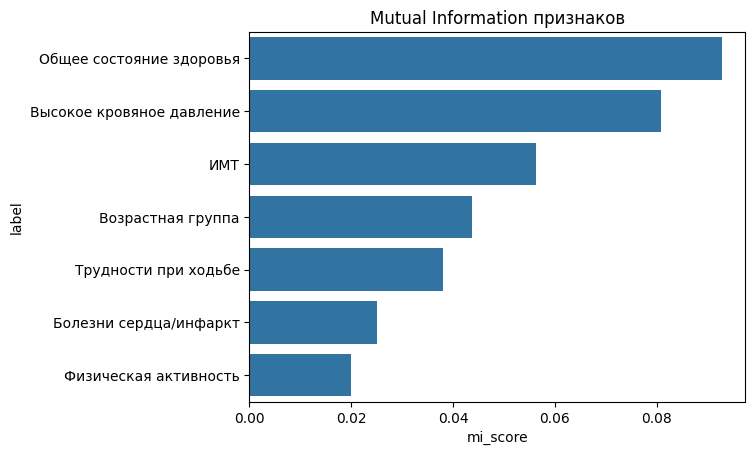

In [4]:
sns.barplot(data=scores, x="mi_score", y="label")
plt.title("Mutual Information признаков")
plt.show()

**Интерпретация результатов**
Наиболее информативными признаками оказались:

- Общее состояние здоровья
- Высокое давление
- BMI
- Возраст

Результаты соответствуют медицинским исследованиям, связанным с факторами риска диабета.


**Выводы**
1. Все выбранные признаки обладают информативностью.
2. Наиболее значимыми факторами являются:
   - общее состояние здоровья,
   - давление,
   - BMI,
   - возраст.
3. Результаты отбора признаков согласуются с медицинской логикой и результатами EDA.
4. Набор признаков подходит для построения модели классификации.